# Lab 6: EEG raw signal analysis


In [3]:
!git clone https://github.com/joseverameza/GRUPO4-ISB-2026-II.git
%cd GRUPO4-ISB-2026-II/Laboratorios/Lab_06
!ls Data

Cloning into 'GRUPO4-ISB-2026-II'...
remote: Enumerating objects: 995, done.
remote: Counting objects: 100% (372/372), done.
remote: Compressing objects: 100% (303/303), done.
remote: Total 995 (delta 224), reused 107 (delta 63), pack-reused 623 (from 2)
Receiving objects: 100% (995/995), 94.57 MiB | 22.41 MiB/s, done.
Resolving deltas: 100% (483/483), done.
/content/GRUPO4-ISB-2026-II/Laboratorios/Lab_06
EEG_ABRE_CIERRA.h5   EEG_FIJO.txt	  EEG_PREGUNTAS_DIFICILES.h5
EEG_ABRE_CIERRA.txt  EEG_MUSICA_LOFI.h5   EEG_PREGUNTAS_DIFICILES.txt
EEG_BASAL.h5	     EEG_MUSICA_LOFI.txt  EEG_PREGUNTAS_FACIL.h5
EEG_BASAL.txt	     EEG_MUSICA_ROCK.h5   EEG_PREGUNTAS_FACIL.txt
EEG_FIJO.h5	     EEG_MUSICA_ROCK.txt  readme.md


In [4]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.integrate import trapezoid

DATA_DIR = Path("Data")
FILES = {
    "Basal": "EEG_BASAL.txt",
    "Eyes open/close (5x5 s)": "EEG_ABRE_CIERRA.txt",
    "Fixed point (30 s)": "EEG_FIJO.txt",
    "Easy questions": "EEG_PREGUNTAS_FACIL.txt",
    "Hard questions": "EEG_PREGUNTAS_DIFICILES.txt",
    "Lofi music": "EEG_MUSICA_LOFI.txt",
    "Rock music": "EEG_MUSICA_ROCK.txt",
}

# BITalino EEG transfer function constants
VCC = 3.3        # supply voltage (V)
G_EEG = 41782    # sensor gain

# Classic EEG bands (Hz)
BANDS = {"Delta": (0.5, 4), "Theta": (4, 8), "Alpha": (8, 13), "Beta": (13, 30), "Gamma": (30, 45)}

## 1. Read OpenSignals file and convert ADC to µV

In [5]:
def read_opensignals(path):
    """Read an OpenSignals .txt file and return the EEG channel in µV plus metadata."""
    with open(path, encoding="utf-8") as f:
        f.readline()                                   # line 1: file format info
        header = json.loads(f.readline().lstrip("#").strip())  # line 2: JSON metadata
    meta = next(iter(header.values()))                 # metadata of the (only) device

    data = np.loadtxt(path, comments="#")              # skips all header lines
    columns = meta["column"]
    fs = meta["sampling rate"]

    # Locate the EEG channel through the sensor list; fall back to the first analog channel
    sensors, labels = meta["sensor"], meta["label"]
    idx = next((i for i, s in enumerate(sensors) if "EEG" in s.upper()), 0)
    col = columns.index(labels[idx])

    res = meta["resolution"]
    n_bits = res[col] if len(res) == len(columns) else res[idx]

    adc = data[:, col]
    eeg_uv = ((adc / 2**n_bits) - 0.5) * VCC / G_EEG * 1e6   # BITalino EEG transfer function
    t = np.arange(len(adc)) / fs
    return {"t": t, "eeg": eeg_uv, "adc": adc, "fs": fs, "n_bits": n_bits, "label": labels[idx]}

records = {name: read_opensignals(DATA_DIR / fname) for name, fname in FILES.items()}
for name, r in records.items():
    print(f"{name}: fs = {r['fs']} Hz | channel {r['label']} | {r['n_bits']} bits | "
          f"duration = {r['t'][-1]:.1f} s | samples = {len(r['eeg'])}")

Basal: fs = 1000 Hz | channel A1 | 10 bits | duration = 122.1 s | samples = 122100
Eyes open/close (5x5 s): fs = 1000 Hz | channel A1 | 10 bits | duration = 72.7 s | samples = 72750
Fixed point (30 s): fs = 1000 Hz | channel A1 | 10 bits | duration = 33.1 s | samples = 33150
Easy questions: fs = 1000 Hz | channel A4 | 10 bits | duration = 111.7 s | samples = 111750
Hard questions: fs = 1000 Hz | channel A4 | 10 bits | duration = 92.8 s | samples = 92850
Lofi music: fs = 1000 Hz | channel A4 | 10 bits | duration = 94.3 s | samples = 94350
Rock music: fs = 1000 Hz | channel A4 | 10 bits | duration = 75.6 s | samples = 75600


## 2. Descriptive statistics and saturation check

In [6]:
for name, r in records.items():
    x, adc_max = r["eeg"], 2**r["n_bits"] - 1
    clipped = np.mean((r["adc"] <= 0) | (r["adc"] >= adc_max)) * 100
    print(f"{name}\n  mean = {x.mean():.2f} µV | std = {x.std():.2f} µV | "
          f"min = {x.min():.2f} µV | max = {x.max():.2f} µV | saturated samples = {clipped:.2f} %")

Basal
  mean = -0.16 µV | std = 2.80 µV | min = -16.20 µV | max = 18.20 µV | saturated samples = 0.00 %
Eyes open/close (5x5 s)
  mean = -0.12 µV | std = 4.62 µV | min = -28.38 µV | max = 34.40 µV | saturated samples = 0.00 %
Fixed point (30 s)
  mean = -0.16 µV | std = 3.63 µV | min = -39.49 µV | max = 28.62 µV | saturated samples = 0.10 %
Easy questions
  mean = 0.44 µV | std = 4.46 µV | min = -19.28 µV | max = 19.82 µV | saturated samples = 0.00 %
Hard questions
  mean = 0.44 µV | std = 4.45 µV | min = -19.36 µV | max = 22.75 µV | saturated samples = 0.00 %
Lofi music
  mean = 0.46 µV | std = 4.59 µV | min = -20.98 µV | max = 18.28 µV | saturated samples = 0.00 %
Rock music
  mean = 0.46 µV | std = 4.62 µV | min = -20.83 µV | max = 19.05 µV | saturated samples = 0.00 %


## 3. Raw signal in the time domain

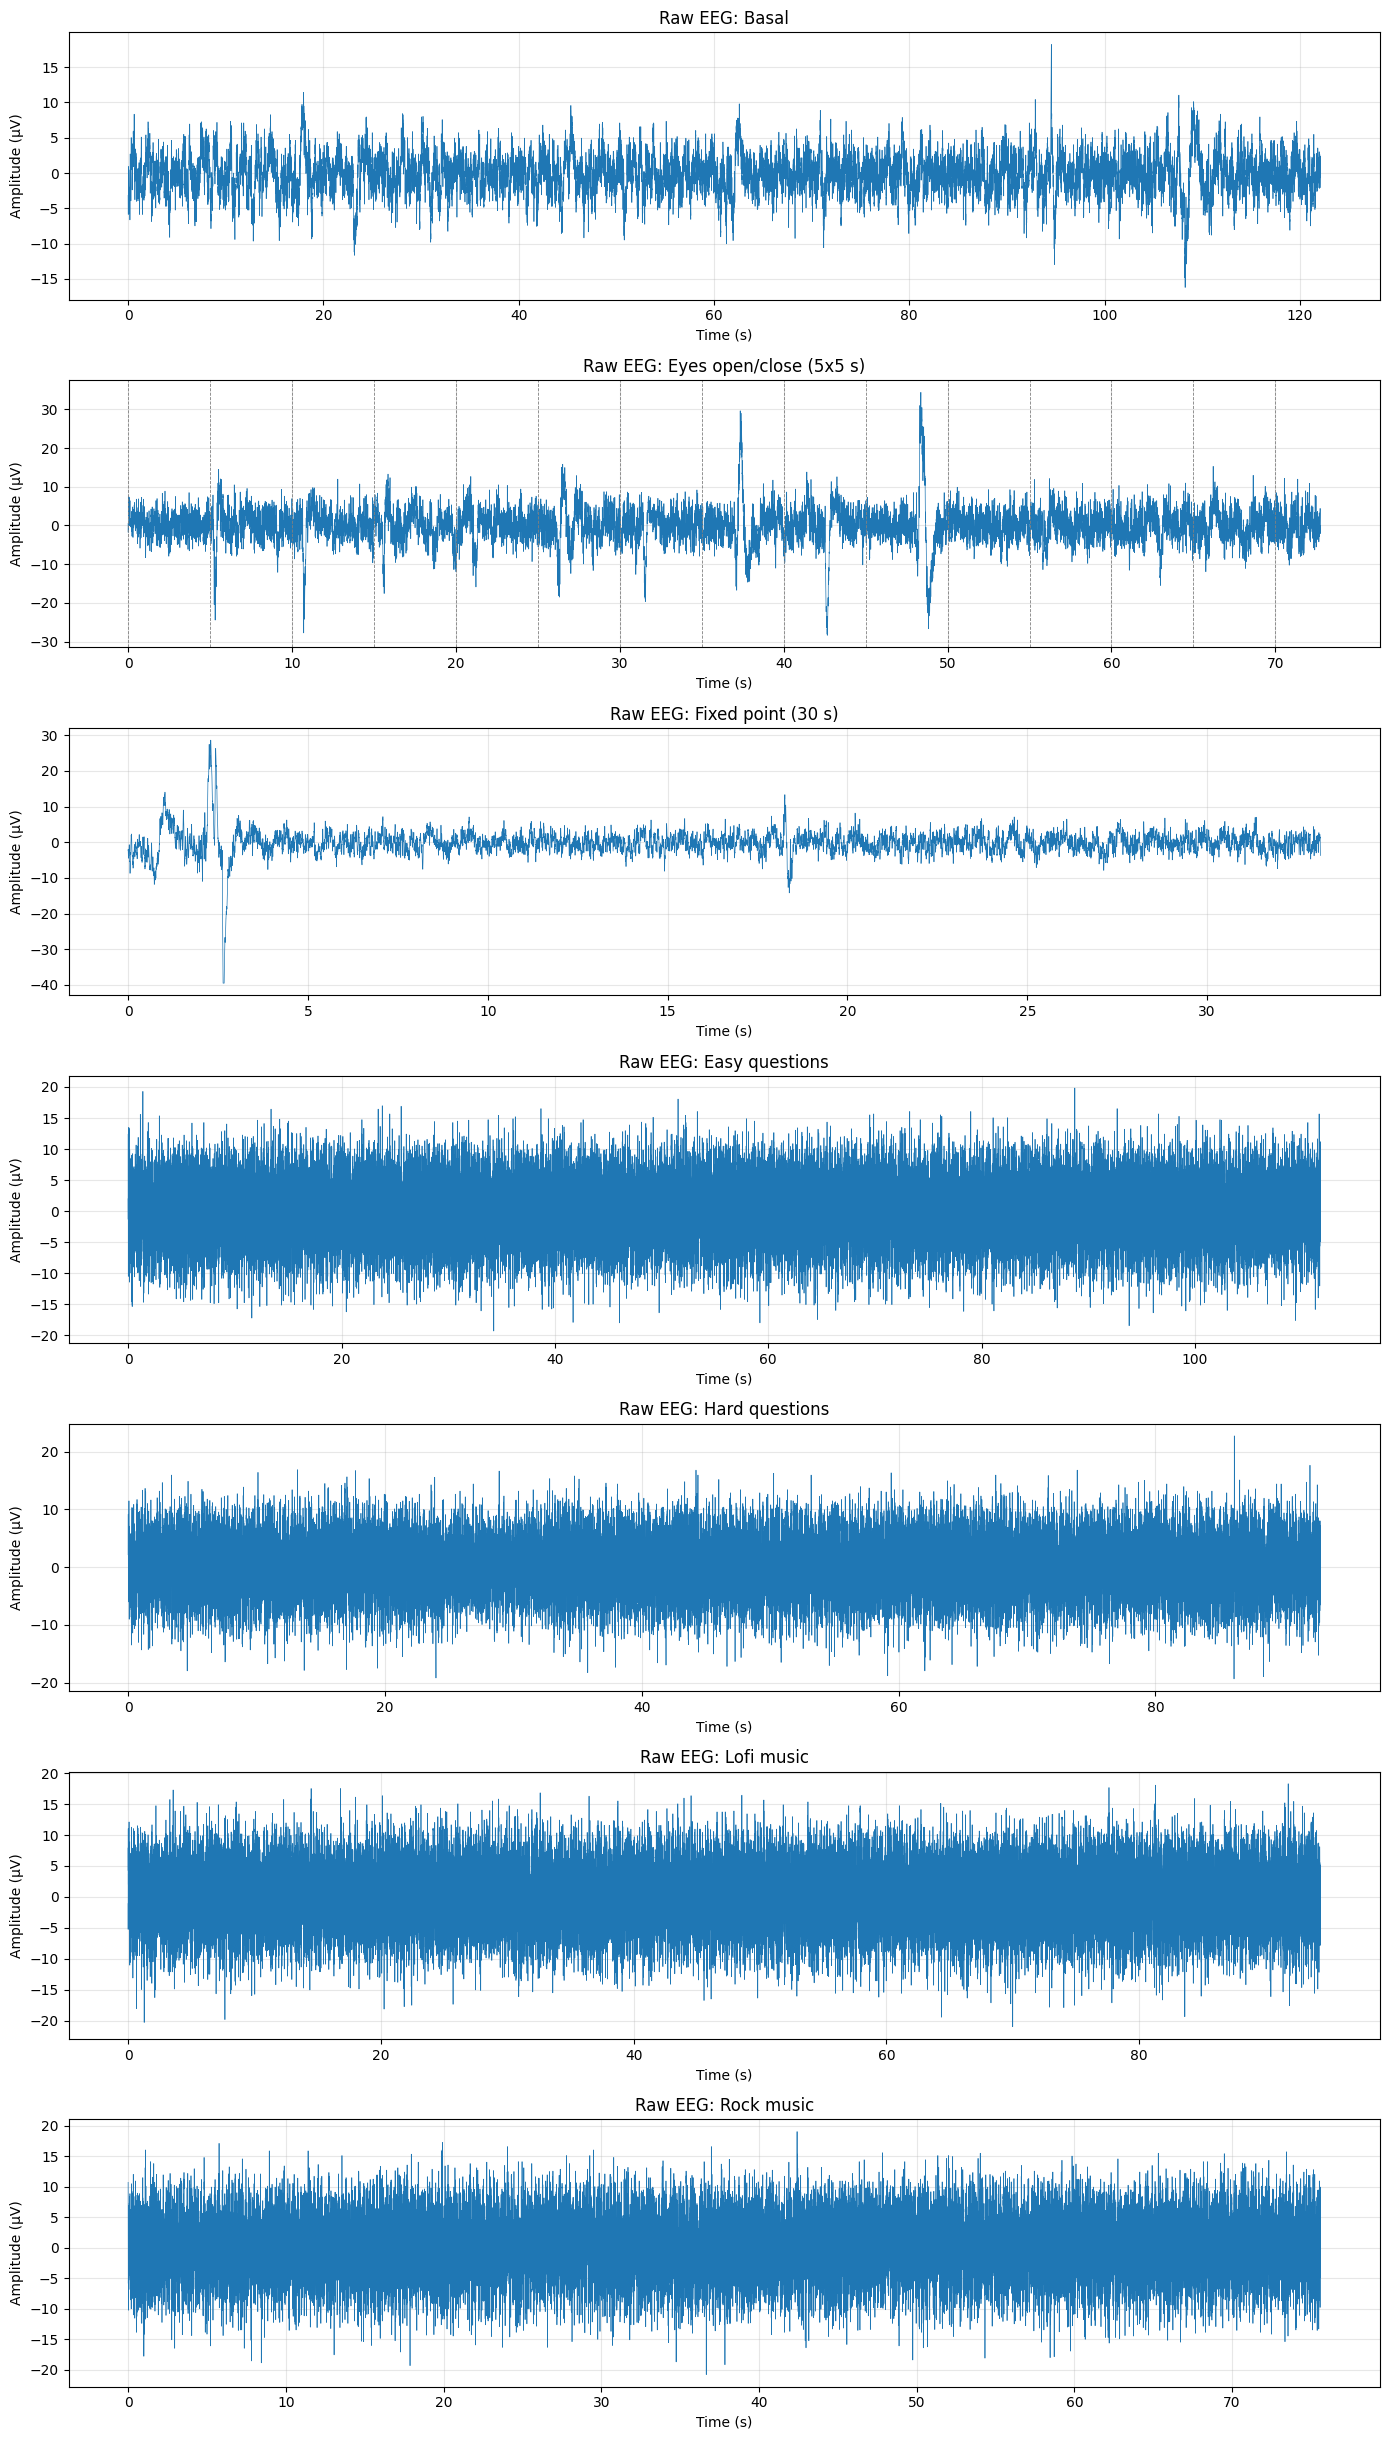

In [7]:
SHOW_5S_GRID = True   # dashed lines every 5 s as a rough reference for the open/close cycles

fig, axes = plt.subplots(len(records), 1, figsize=(14, 3.5 * len(records)))
for ax, (name, r) in zip(np.atleast_1d(axes), records.items()):
    ax.plot(r["t"], r["eeg"], lw=0.5)
    if SHOW_5S_GRID and "open/close" in name:
        for tc in np.arange(0, r["t"][-1], 5):
            ax.axvline(tc, color="gray", ls="--", lw=0.6)
    ax.set(title=f"Raw EEG: {name}", xlabel="Time (s)", ylabel="Amplitude (µV)")
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Power spectral density (Welch)

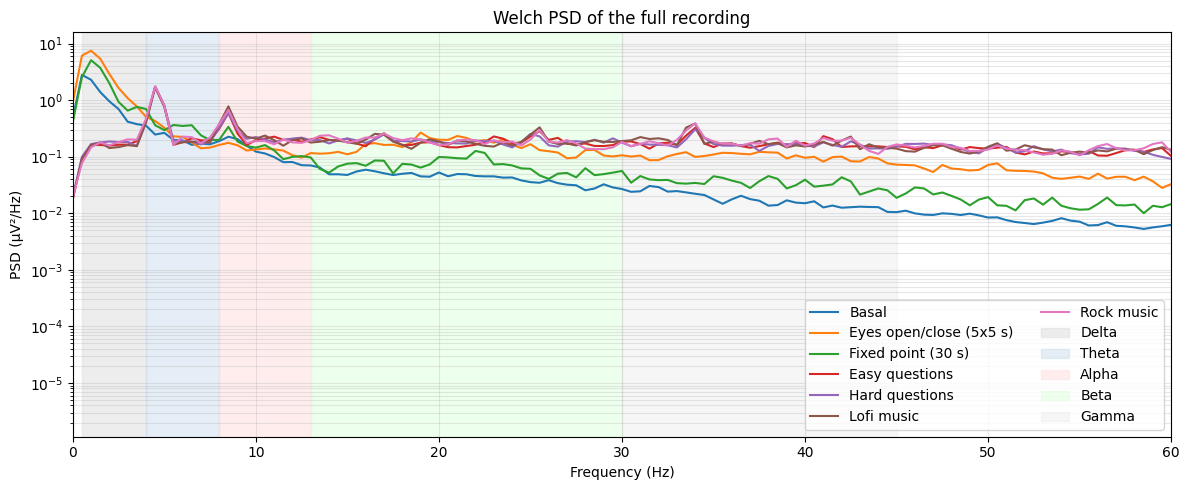

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
psd = {}
for name, r in records.items():
    f, pxx = signal.welch(r["eeg"], fs=r["fs"], nperseg=int(2 * r["fs"]))  # 2 s windows -> 0.5 Hz resolution
    psd[name] = (f, pxx)
    ax.semilogy(f, pxx, label=name)

colors = ["#ddd", "#cde", "#fdd", "#dfd", "#eee"]
for (band, (lo, hi)), c in zip(BANDS.items(), colors):
    ax.axvspan(lo, hi, color=c, alpha=0.5, label=band)
ax.set(xlim=(0, 60), xlabel="Frequency (Hz)", ylabel="PSD (µV²/Hz)", title="Welch PSD of the full recording")
ax.legend(ncol=2); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## 5. Spectrogram (time-frequency)

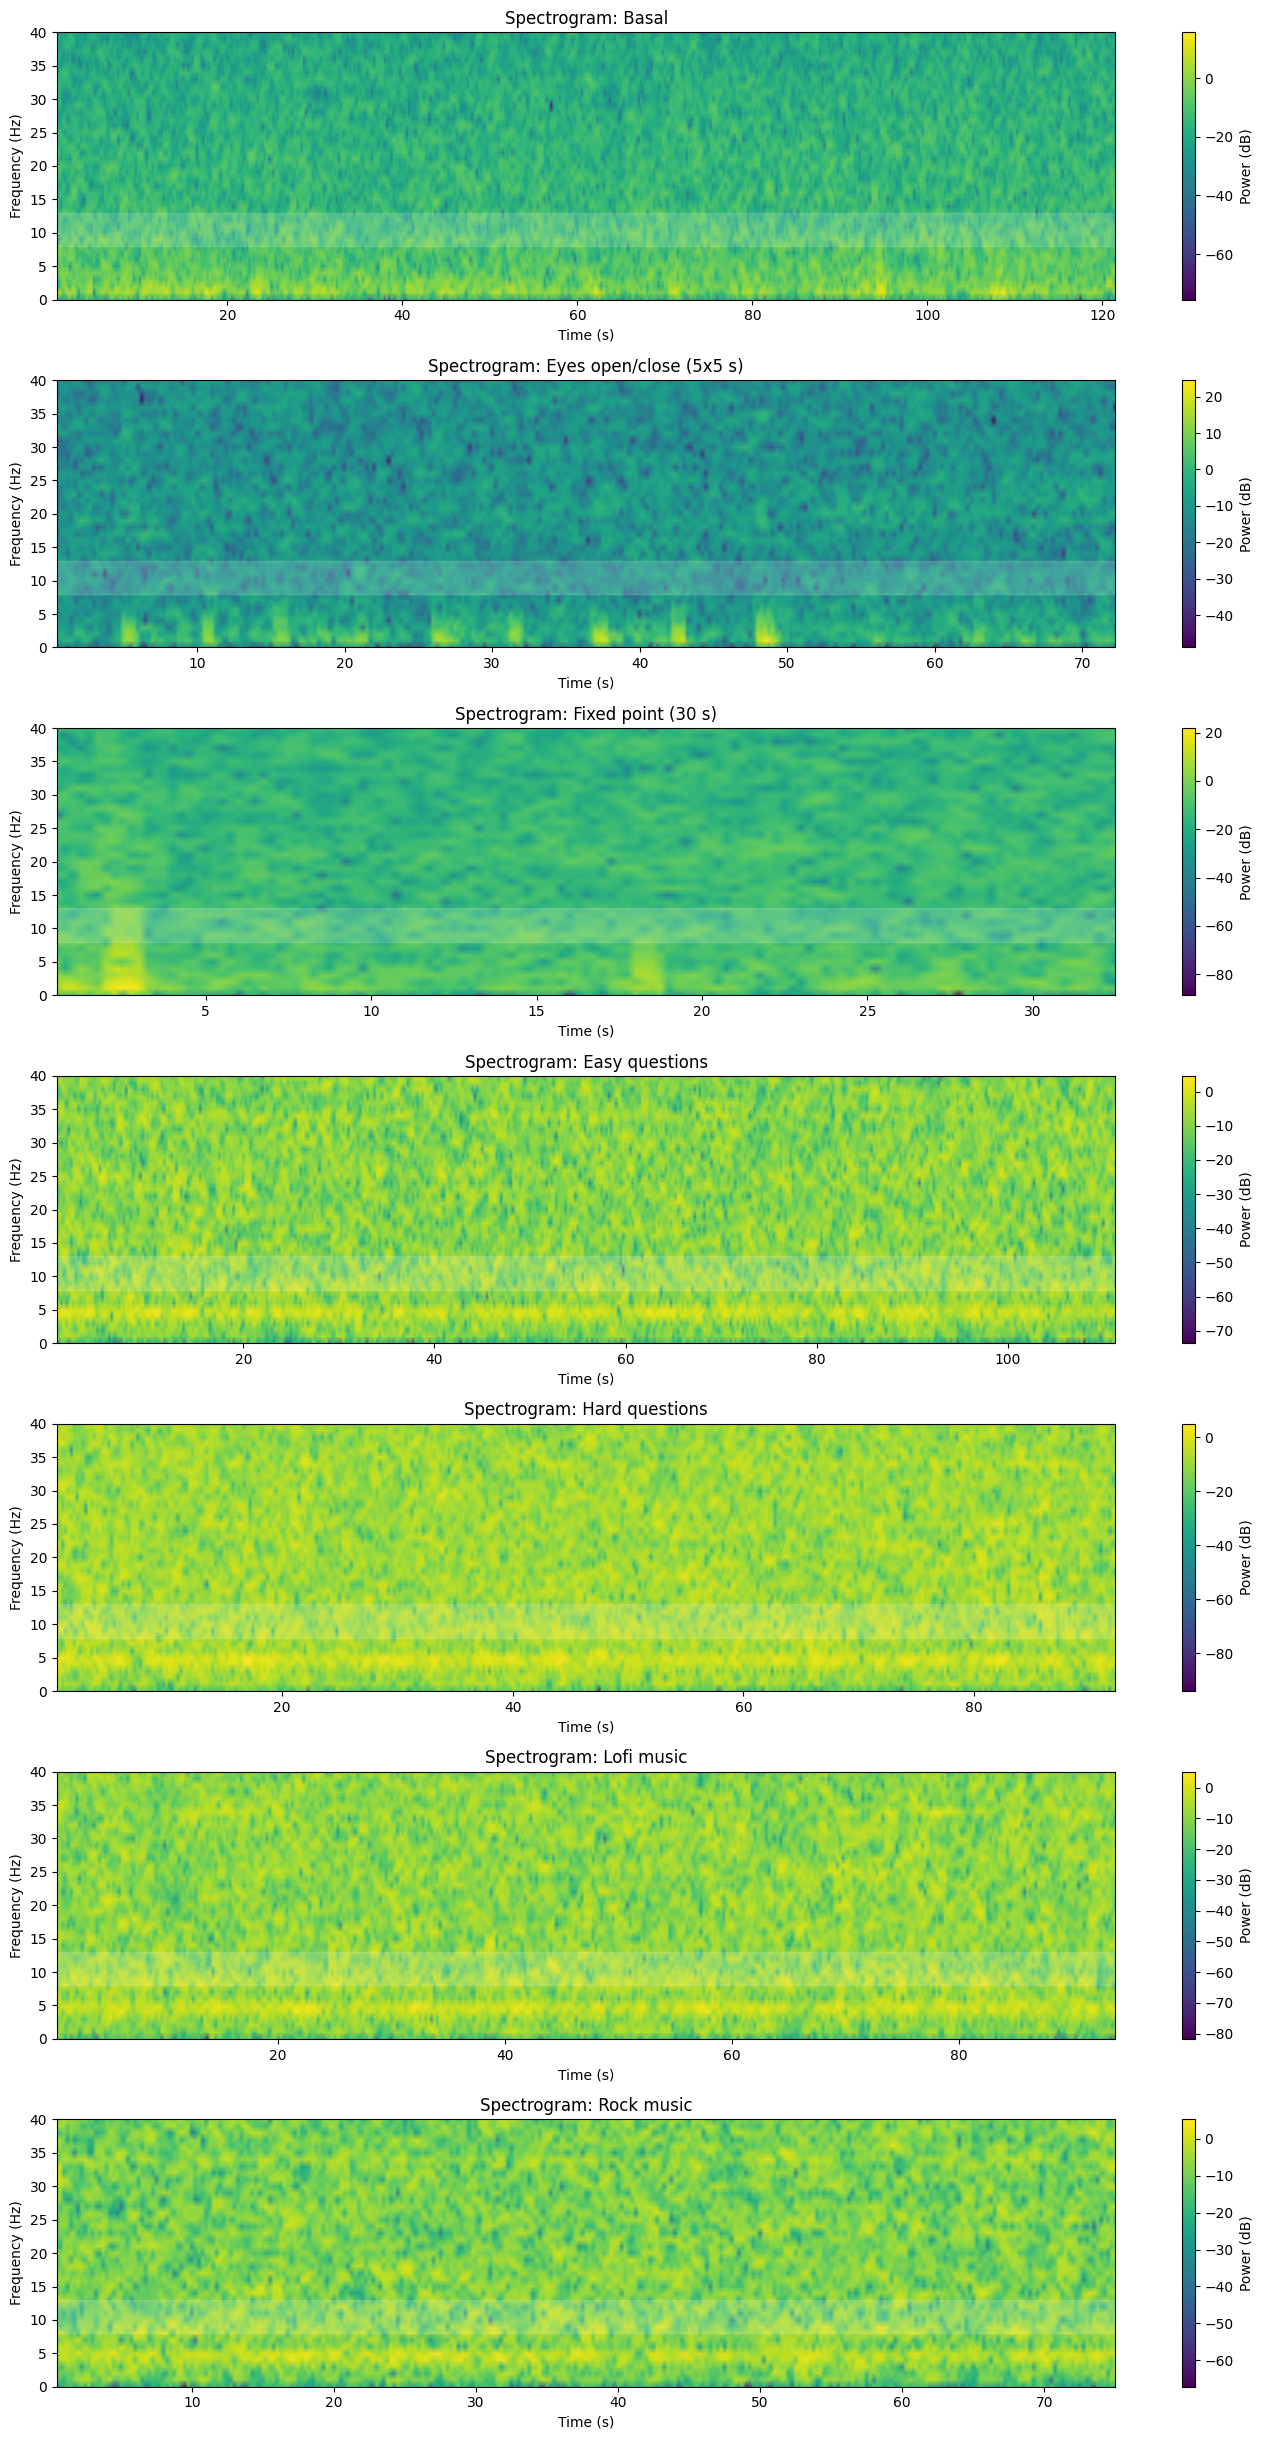

In [9]:
fig, axes = plt.subplots(len(records), 1, figsize=(14, 3.5 * len(records)))
for ax, (name, r) in zip(np.atleast_1d(axes), records.items()):
    f, t, sxx = signal.spectrogram(r["eeg"], fs=r["fs"], nperseg=int(r["fs"]), noverlap=int(0.75 * r["fs"]))
    keep = f <= 40
    im = ax.pcolormesh(t, f[keep], 10 * np.log10(sxx[keep] + 1e-12), shading="gouraud", cmap="viridis")
    ax.axhspan(8, 13, color="white", alpha=0.15)   # alpha band highlight
    ax.set(title=f"Spectrogram: {name}", xlabel="Time (s)", ylabel="Frequency (Hz)")
    fig.colorbar(im, ax=ax, label="Power (dB)")
plt.tight_layout(); plt.show()

## 6. Relative band power

In [10]:
def band_powers(f, pxx):
    total = trapezoid(pxx[(f >= 0.5) & (f <= 45)], f[(f >= 0.5) & (f <= 45)])
    return {b: trapezoid(pxx[(f >= lo) & (f < hi)], f[(f >= lo) & (f < hi)]) / total * 100
            for b, (lo, hi) in BANDS.items()}

print(f"{'Record':28s}" + "".join(f"{b:>9s}" for b in BANDS))
for name, (f, pxx) in psd.items():
    bp = band_powers(f, pxx)
    print(f"{name:28s}" + "".join(f"{v:8.1f}%" for v in bp.values()))

Record                          Delta    Theta    Alpha     Beta    Gamma
Basal                           57.8%    11.8%     9.6%    11.5%     4.2%
Eyes open/close (5x5 s)         64.1%     5.4%     3.6%    15.1%     8.7%
Fixed point (30 s)              62.7%    10.8%     6.5%    10.5%     4.6%
Easy questions                   5.0%    18.7%    12.0%    32.2%    26.4%
Hard questions                   5.3%    18.7%    12.4%    32.5%    25.3%
Lofi music                       4.6%    17.5%    13.3%    31.5%    27.6%
Rock music                       5.0%    18.5%    11.8%    31.8%    27.2%
